In [ ]:
print("HI")

[1] "HI"


In [ ]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [ ]:
head(iris)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa


In [ ]:
if (!requireNamespace("patchwork", quietly = TRUE)) {
  install.packages("patchwork")
}
library(patchwork)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



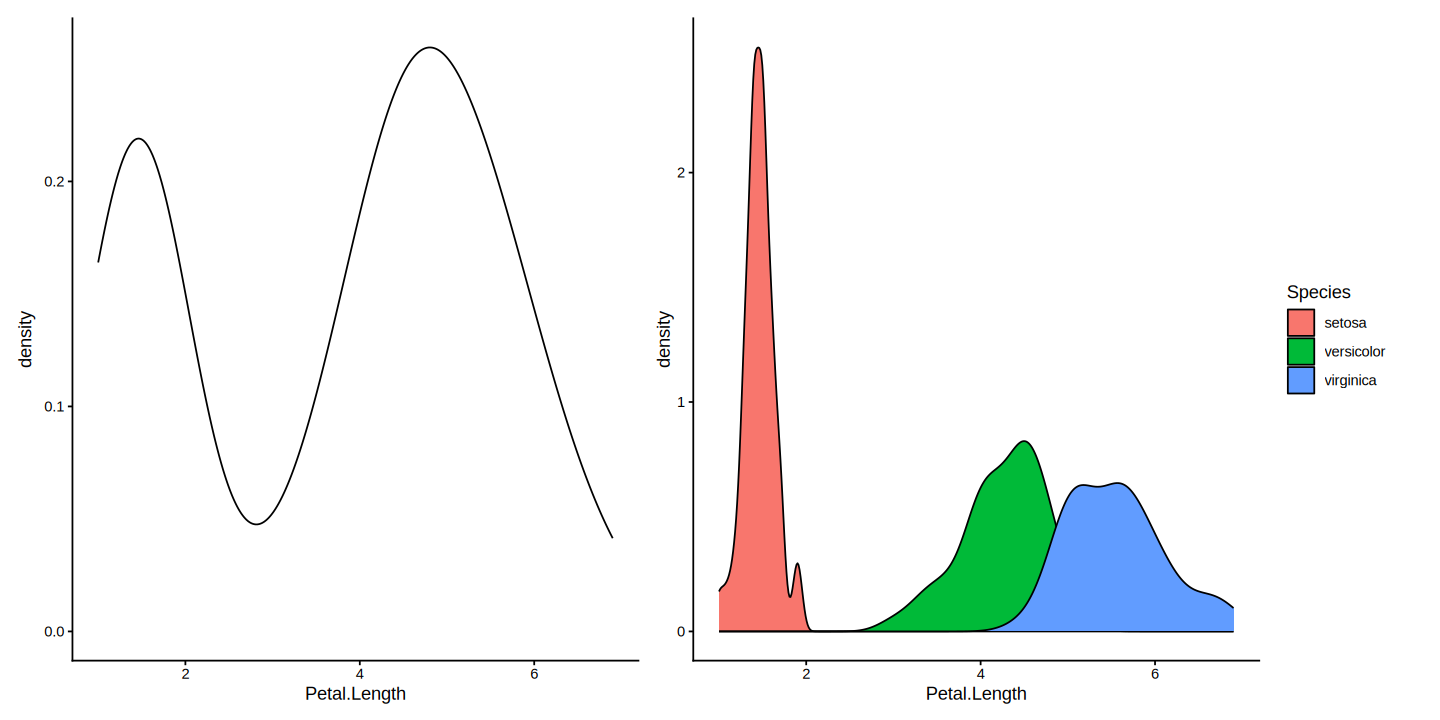

In [ ]:
options(repr.plot.width = 12, repr.plot.height = 6)
feature <- "Petal.Length"
p1 <- iris |>
  ggplot(aes(x=.data[[feature]])) +
  geom_density() +
  theme_classic()
p2 <- iris |>
  ggplot(aes(x=.data[[feature]],fill=Species)) +
  geom_density() +
  theme_classic()
p1+p2

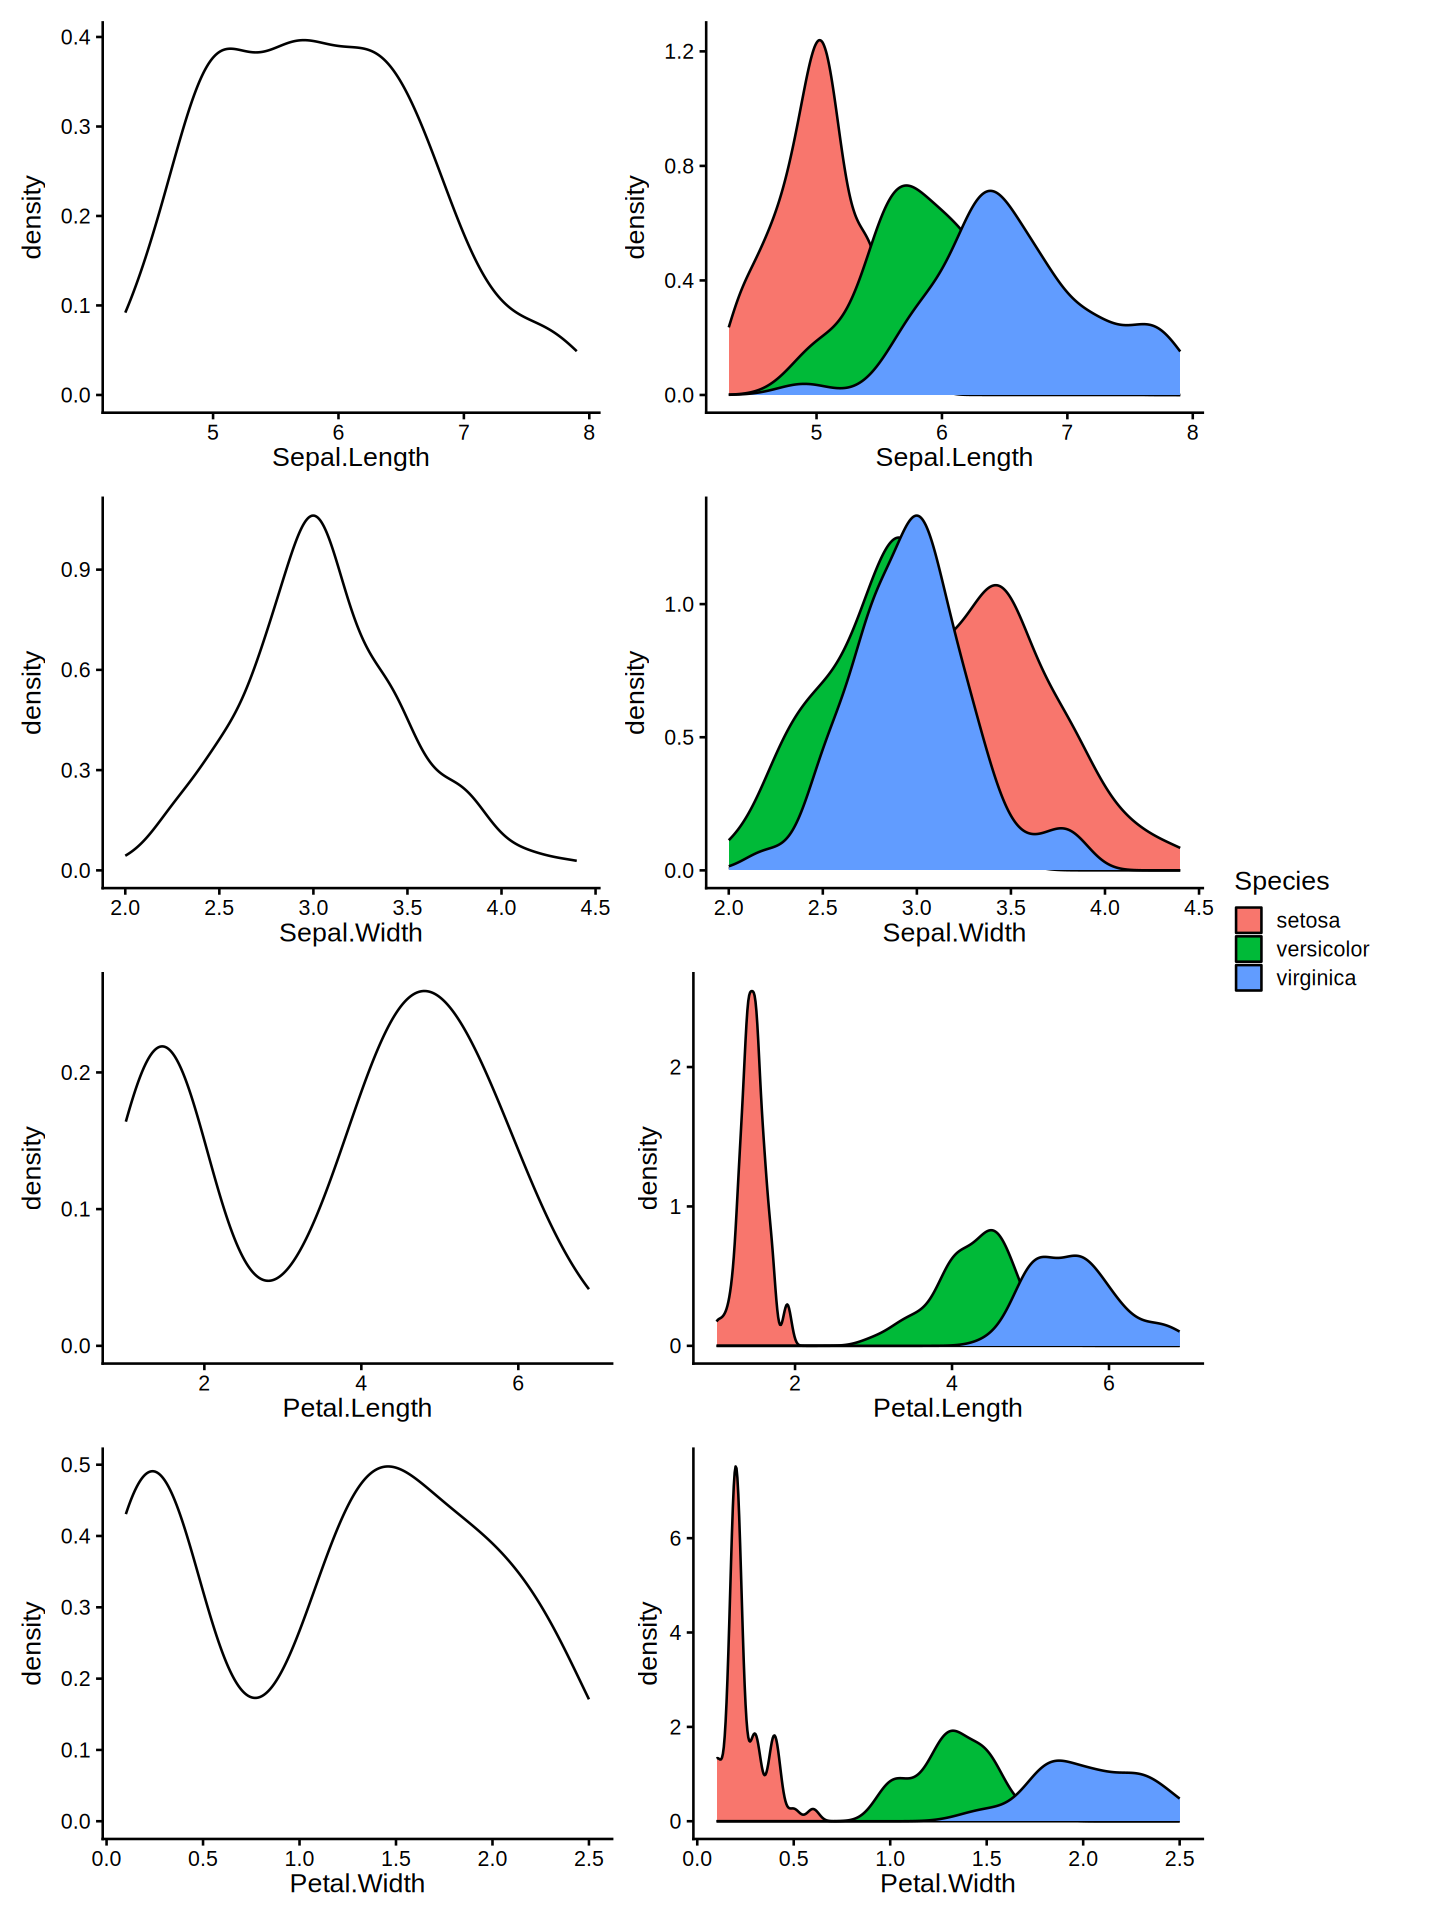

In [ ]:
library(tidyverse)
library(patchwork)

options(repr.plot.width = 12, repr.plot.height = 16)

features <- c("Sepal.Length", "Sepal.Width", "Petal.Length", "Petal.Width")

# Use map() instead of lapply()
row_list <- map(features, ~ {

  p1 <- iris |>
    ggplot(aes(x = .data[[.x]])) +
    geom_density() +
    theme_classic(base_size = 16)

  p2 <- iris |>
    ggplot(aes(x = .data[[.x]], fill = Species)) +
    geom_density() +
    theme_classic(base_size = 16)

  p1 + p2
})

# Stack them into the 4x2 grid
wrap_plots(row_list, ncol = 1) +
  plot_layout(guides = "collect")

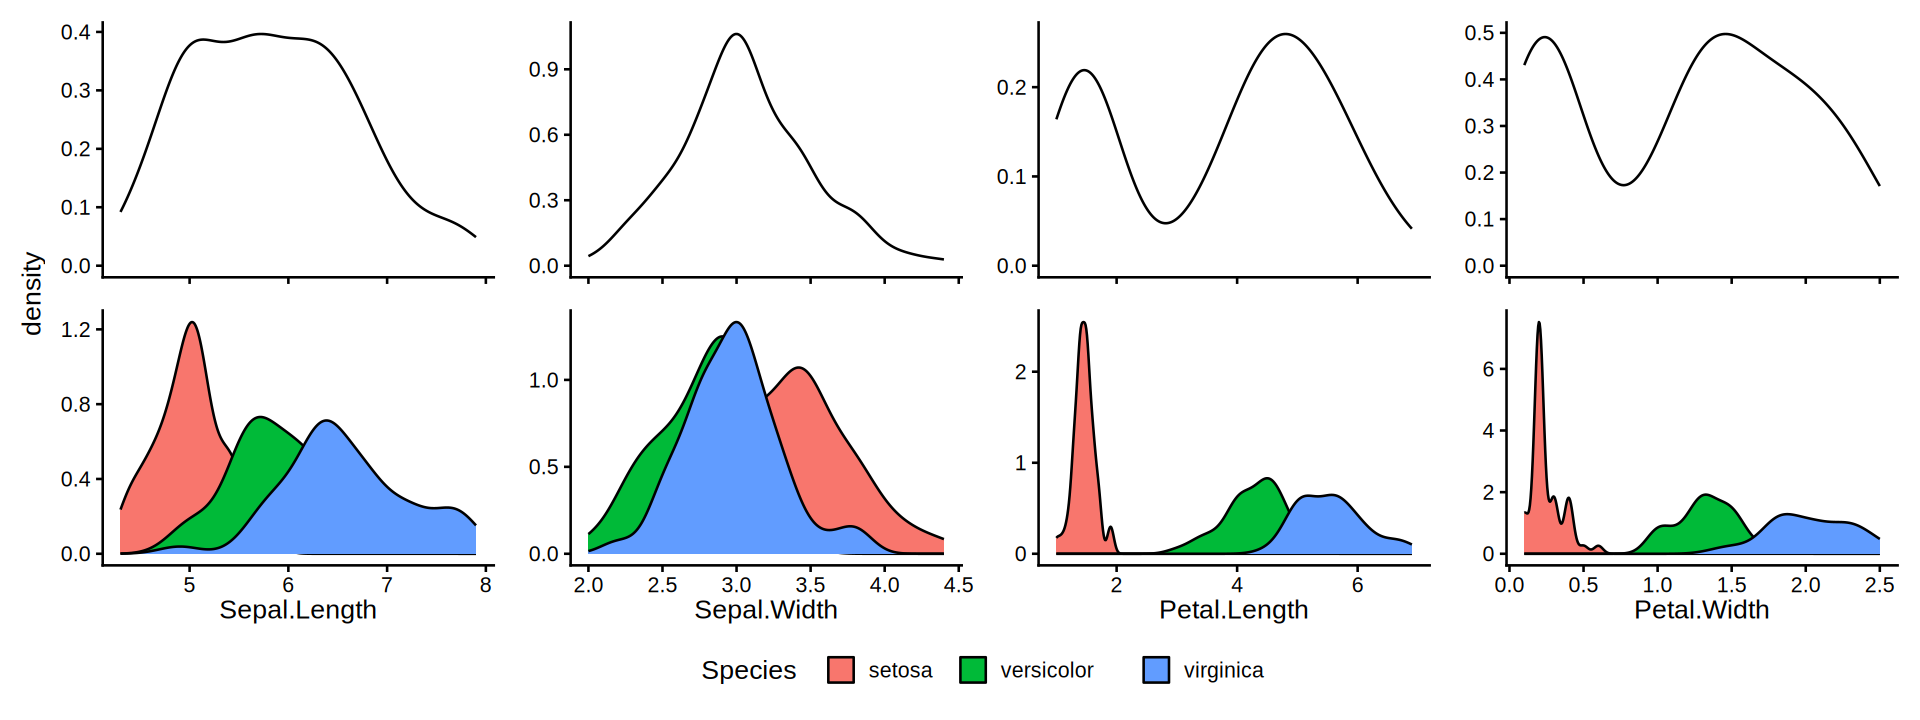

In [ ]:
# Adjust dimensions for a wider 2x4 grid
options(repr.plot.width = 16, repr.plot.height = 6)

features <- c("Sepal.Length", "Sepal.Width", "Petal.Length", "Petal.Width")

# Row 1: Plain density plots (4 columns)
row1 <- map(features, \(feat) {
  ggplot(iris, aes(x = .data[[feat]])) +
    geom_density() +
    theme_classic(base_size = 16) +
    theme(
      axis.text.x = element_blank(),  # Removes the numbers, leaves the line & ticks
      axis.title.x = element_blank()
    )
})

# Row 2: Species-filled density plots (4 columns)
row2 <- map(features, \(feat) {
  ggplot(iris, aes(x = .data[[feat]], fill = Species)) +
    geom_density() +
    theme_classic(base_size = 16)
})

# Combine both rows and set ncol = 4
all_plots <- c(row1, row2)

wrap_plots(all_plots, ncol = 4) +
  plot_layout(axes = "collect_y", guides = "collect") &
  theme(legend.position = "bottom")

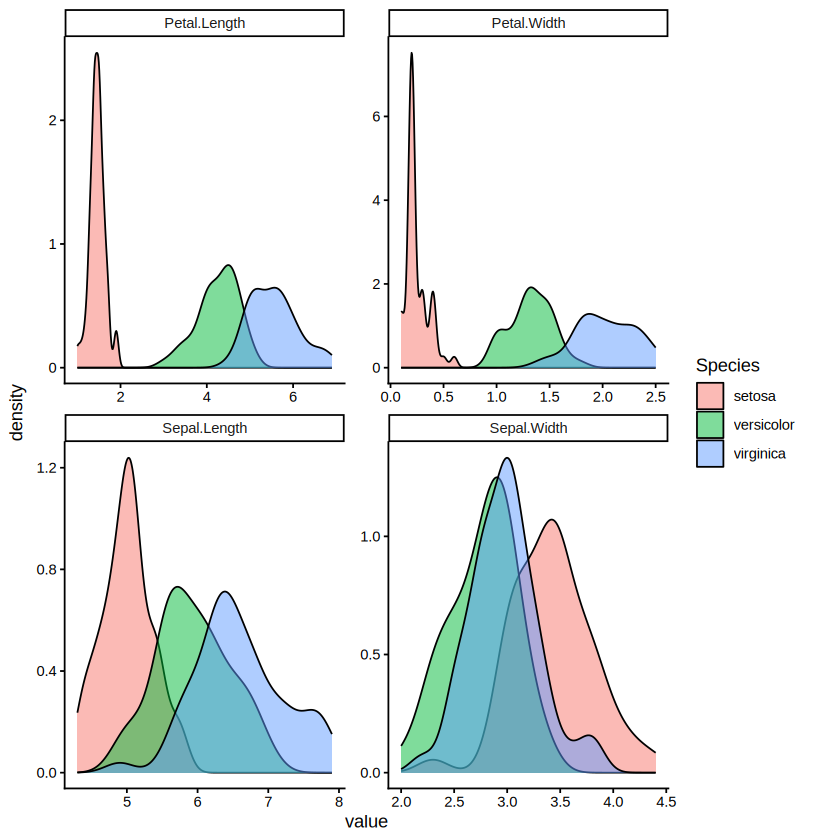

In [ ]:
iris |>
  pivot_longer(cols = -Species, names_to = "feature", values_to = "value") |>
  ggplot(aes(x = value, fill = Species)) +
  geom_density(alpha = 0.5) +
  facet_wrap(~feature, scales = "free") +
  theme_classic()

## PMF

If the variable has gaps where values are impossible (you can have 2  or 3, but not 2.5), use a PMF. If the variable can flow smoothly through an infinite number of fractions, use a PDF.



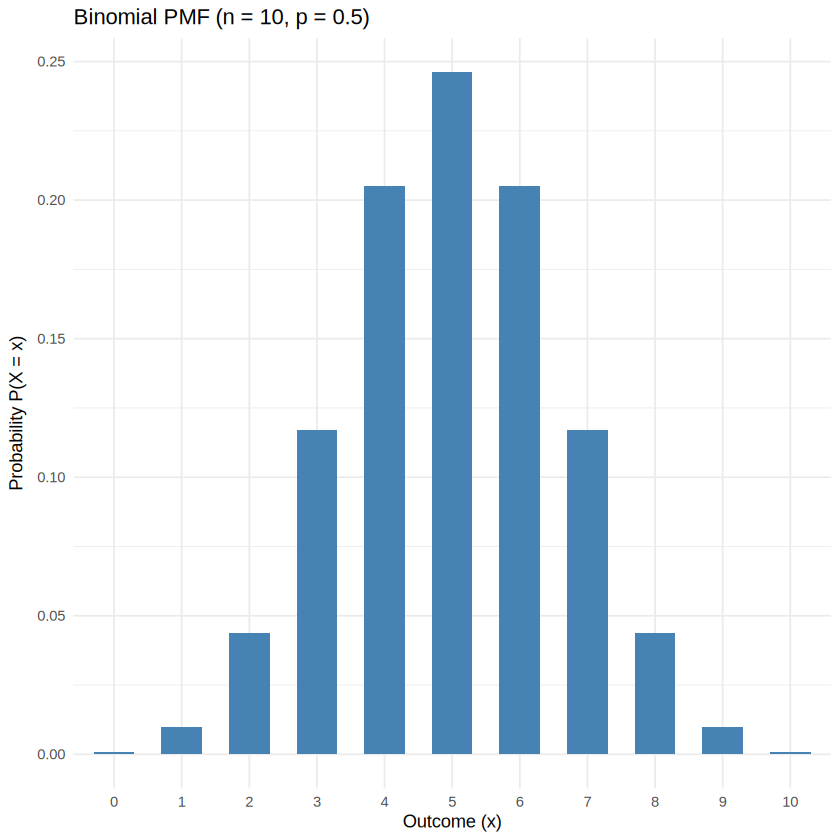

In [1]:
library(ggplot2)

# 1. Define the discrete outcomes and calculate their PMF probabilities
x <- 0:10
prob <- dbinom(x, size = 10, prob = 0.5)

# 2. Combine into a data frame
pmf_data <- data.frame(x = factor(x), prob = prob)

# 3. Create the PMF bar plot
ggplot(pmf_data, aes(x = x, y = prob)) +
  geom_col(fill = "steelblue", width = 0.6) +
  labs(
    title = "Binomial PMF (n = 10, p = 0.5)",
    x = "Outcome (x)",
    y = "Probability P(X = x)"
  ) +
  theme_minimal()

In [6]:
prob

[1] 0.0009765625 0.0097656250 0.0439453125 0.1171875000 0.2050781250
 [6] 0.2460937500 0.2050781250 0.1171875000 0.0439453125 0.0097656250
[11] 0.0009765625

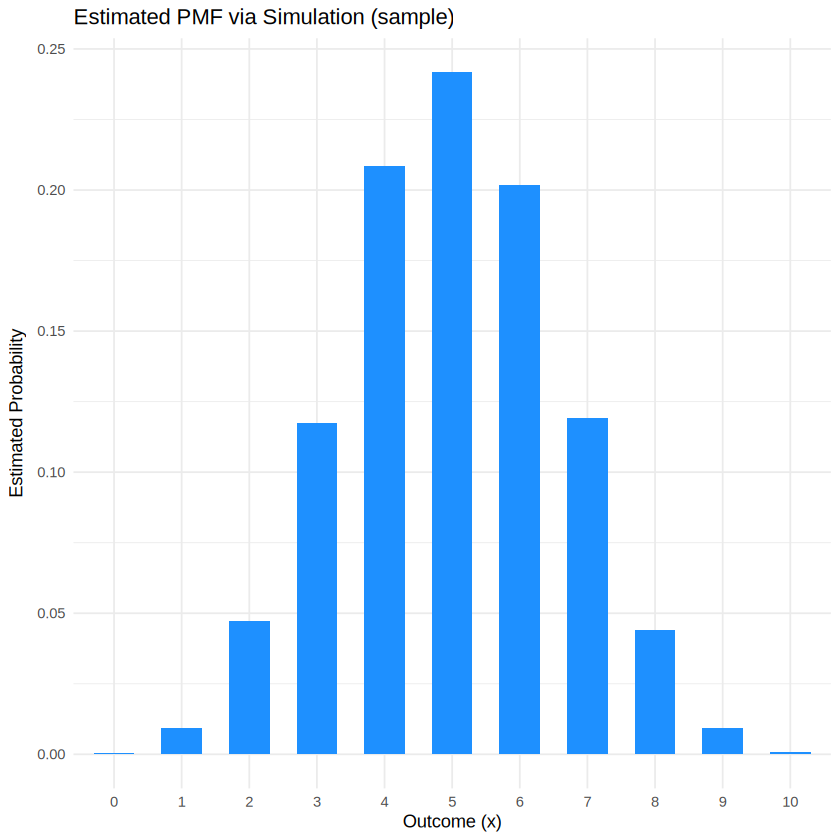

In [11]:
library(ggplot2)

set.seed(42)

# 1. Simulate flipping a fair coin 10 times, repeated 10,000 times
# We use replicate() to simulate 10 coin flips (0 or 1) and sum them up
trials <- replicate(10000, sum(sample(c(0, 1), size = 10, replace = TRUE, prob = c(0.5, 0.5))))

# 2. Turn the simulated counts into proportions (estimated probabilities)
sim_data <- as.data.frame(table(trials))
sim_data$prob <- sim_data$Freq / sum(sim_data$Freq)
sim_data$trials <- as.numeric(as.character(sim_data$trials))

# 3. Plot the simulated PMF
ggplot(sim_data, aes(x = factor(trials), y = prob)) +
  geom_col(fill = "dodgerblue", width = 0.6) +
  labs(
    title = "Estimated PMF via Simulation (sample)",
    x = "Outcome (x)",
    y = "Estimated Probability"
  ) +
  theme_minimal()

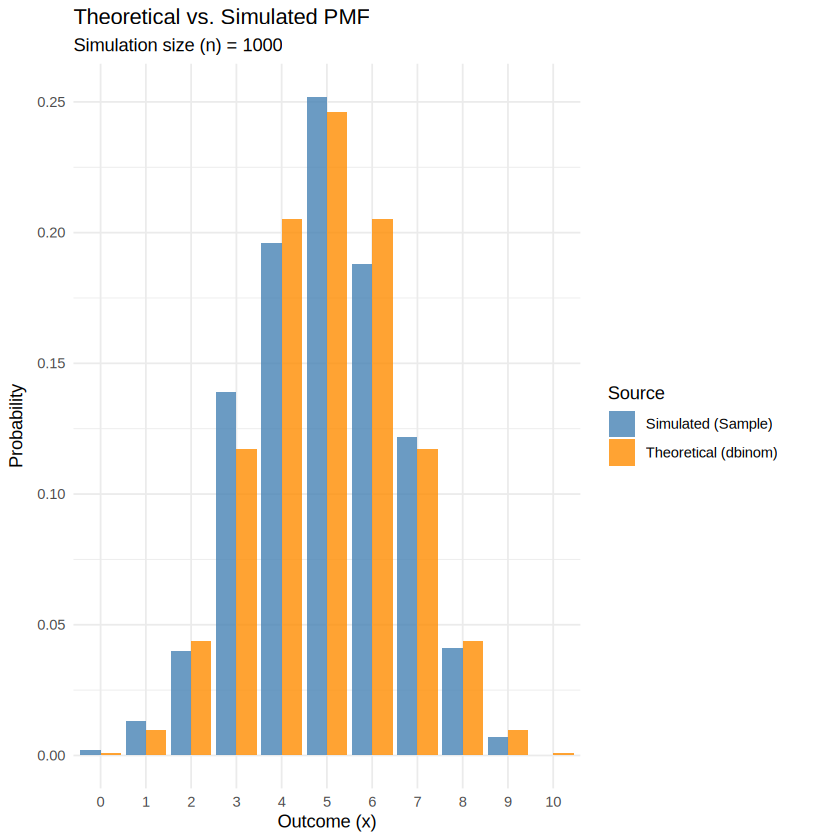

In [15]:
library(ggplot2)
library(dplyr)

set.seed(42)
n_trials <- 10
p <- 0.5
n_sim <- 1000 # Try changing this to 50 vs 10,000 to see what happens!

# 1. Theoretical Data (dbinom)
x_vals <- 0:n_trials
theo_df <- data.frame(
  x = x_vals,
  prob = dbinom(x_vals, size = n_trials, prob = p),
  Source = "Theoretical (dbinom)"
)

# 2. Simulated Data (rbinom / sample-based)
sim_data <- rbinom(n_sim, size = n_trials, prob = p)
sim_df <- data.frame(x = sim_data) %>%
  count(x) %>%
  mutate(prob = n / n_sim, Source = "Simulated (Sample)") %>%
  select(-n)

# Ensure all x values (0 to 10) are present in simulation data (fill missing with 0)
sim_df <- merge(data.frame(x = x_vals), sim_df, all.x = TRUE)
sim_df$prob[is.na(sim_df$prob)] <- 0
sim_df$Source <- "Simulated (Sample)"

# 3. Combine both into one data frame
comparison_df <- rbind(theo_df, sim_df)

# 4. Plot them side-by-side
ggplot(comparison_df, aes(x = factor(x), y = prob, fill = Source)) +
  geom_col(position = "dodge", alpha = 0.8) +
  labs(
    title = "Theoretical vs. Simulated PMF",
    subtitle = paste("Simulation size (n) =", n_sim),
    x = "Outcome (x)",
    y = "Probability"
  ) +
  scale_fill_manual(values = c("steelblue", "darkorange")) +
  theme_minimal()

### Mean Absolute Error (MAE)

In [17]:
# Assuming comparison_df from the previous step is ready:
library(tidyr)

# Pivot data wide to easily compare theoretical vs simulated probabilities
wide_df <- comparison_df %>%
  pivot_wider(names_from = Source, values_from = prob)

# Calculate Mean Absolute Error (MAE)
mae <- mean(abs(wide_df$`Theoretical (dbinom)` - wide_df$`Simulated (Sample)`))
cat("Mean Absolute Error:", mae, "\n")

Mean Absolute Error: 0.00668892 


### Chi-Square Goodness-of-Fit Test

In [19]:
# 1. Get simulated counts (frequencies) instead of probabilities
sim_counts <- table(factor(sim_data, levels = 0:10))

# 2. Get expected theoretical counts
expected_probs <- dbinom(0:10, size = 10, prob = 0.5)
expected_counts <- expected_probs * length(sim_data)

# 3. Run the Chi-Square test
chi_test <- chisq.test(sim_counts, p = expected_probs)
print(chi_test)

Warning message in chisq.test(sim_counts, p = expected_probs):
“Chi-squared approximation may be incorrect”



	Chi-squared test for given probabilities

data:  sim_counts
X-squared = 10.679, df = 10, p-value = 0.3831



In [1]:
# 1. Create a contingency matrix with the data
# Rows = Treatment, Columns = Outcome (Recovered, Did Not Recover)
clinical_data <- matrix(
  c(65, 35,   # New Drug counts
    40, 60),  # Placebo counts
  nrow = 2,
  byrow = TRUE,
  dimnames = list(
    Treatment = c("New Drug", "Placebo"),
    Outcome = c("Recovered", "Did Not Recover")
  )
)

# View the contingency table
print("Contingency Table:")
print(clinical_data)

# 2. Run the Chi-Square Test of Independence
chi_result <- chisq.test(clinical_data)

# Print the test results
print(chi_result)

[1] "Contingency Table:"
          Outcome
Treatment  Recovered Did Not Recover
  New Drug        65              35
  Placebo         40              60

	Pearson's Chi-squared test with Yates' continuity correction

data:  clinical_data
X-squared = 11.549, df = 1, p-value = 0.0006779



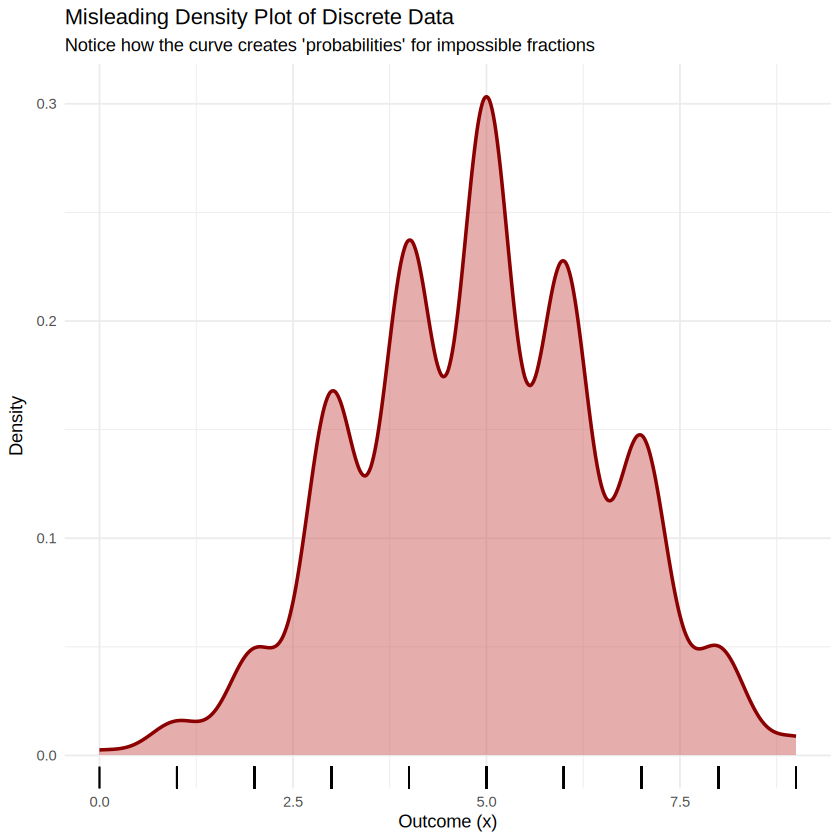

In [5]:
library(ggplot2)

# 1. Generate raw discrete data (e.g., 1,000 samples from a Binomial distribution)
set.seed(42)
raw_data <- data.frame(x = rbinom(1000, size = 10, prob = 0.5))

# 2. Try to force it into a density plot
ggplot(raw_data, aes(x = x)) +
  geom_density(fill = "indianred", alpha = 0.5, color = "darkred", linewidth = 1) +
  geom_rug(sides = "b", color = "black") + # Shows where the actual data points live
  labs(
    title = "Misleading Density Plot of Discrete Data",
    subtitle = "Notice how the curve creates 'probabilities' for impossible fractions",
    x = "Outcome (x)",
    y = "Density"
  ) +
  theme_minimal()

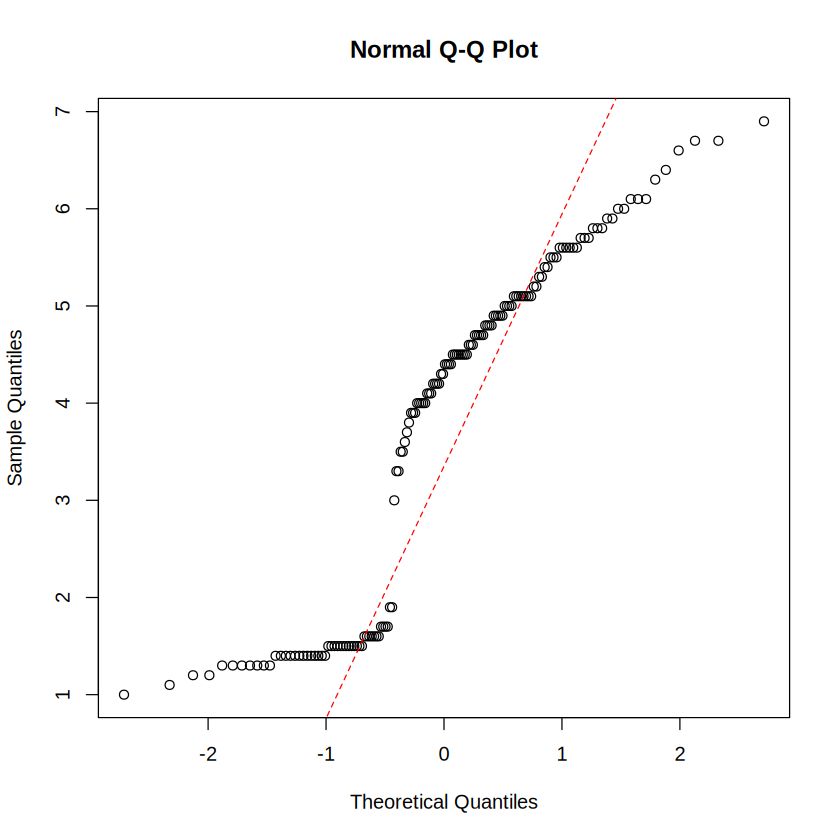

In [ ]:
qqnorm(iris$Petal.Length)
qqline(iris$Petal.Length, col = "red", lty = 2)

In [ ]:
p <- iris |>
  ggplot(aes(sample = Petal.Length)) +
  geom_qq() +
  geom_qq_line(color = "red", linetype = "dashed") +
  theme_classic() +
  labs(
    title = "Q-Q Plot for Petal Length",
    x = "Theoretical Quantiles",
    y = "Sample Quantiles"
  )+
    coord_cartesian(ylim = range(iris$Petal.Length))

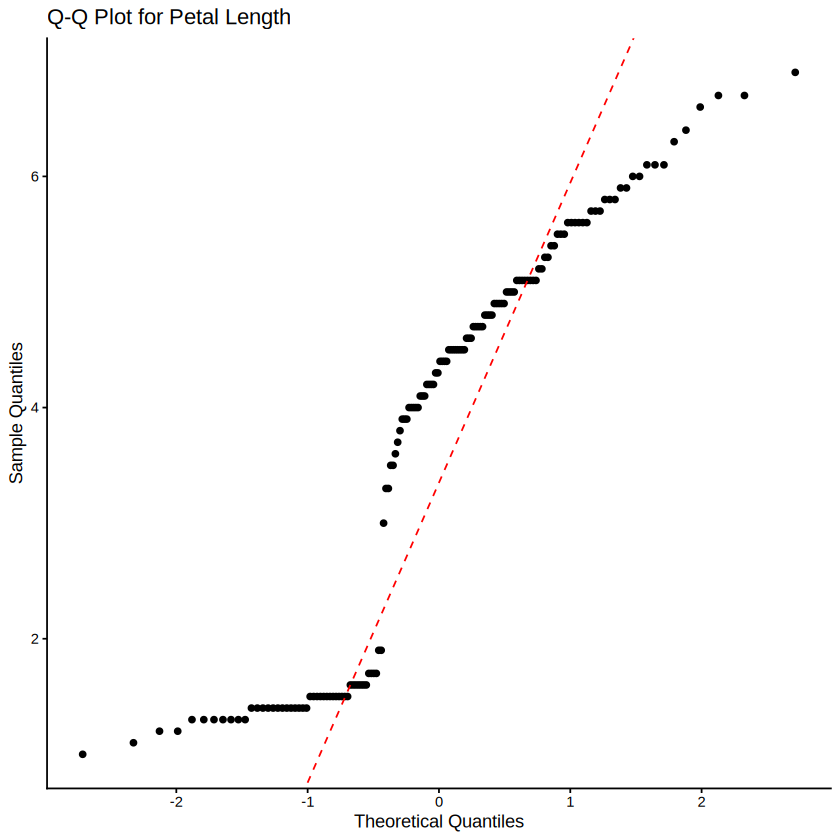

In [ ]:
p

In [ ]:
layer_scales(p)$y$range

<ContinuousRange>
  Inherits from: <Range>
  Public:
    clone: function (deep = FALSE) 
    initialize: function () 
    range: -3.68915931034831 10.3891593103483
    reset: function () 
    train: function (x, call = caller_env()) 

## Normality test

In [ ]:
shapiro.test(iris$Petal.Length)


	Shapiro-Wilk normality test

data:  iris$Petal.Length
W = 0.87627, p-value = 7.412e-10


In [ ]:
ks.test(iris$Petal.Length, "pnorm", mean=mean(iris$Petal.Length), sd=sd(iris$Petal.Length))

Warning message in ks.test.default(iris$Petal.Length, "pnorm", mean = mean(iris$Petal.Length), :
“ties should not be present for the one-sample Kolmogorov-Smirnov test”



	Asymptotic one-sample Kolmogorov-Smirnov test

data:  iris$Petal.Length
D = 0.19815, p-value = 1.532e-05
alternative hypothesis: two-sided


Here is the summary comparison table formatted in Markdown:

| Feature | Shapiro-Wilk (`shapiro.test`) | Kolmogorov-Smirnov (`ks.test`) |
| --- | --- | --- |
| **Primary Purpose** | Specifically tests for normality | General distribution comparison / Goodness-of-fit |
| **Handles Sample Parameters** | Yes (built into the formula) | No, unless a special correction (like Lilliefors) is used |
| **Power for Normality** | High (sensitive to tails and skew) | Lower (less sensitive in the tails) |

In [ ]:
# Extract Petal Lengths for the other two species
versicolor_petal <- iris |>
  filter(Species == "versicolor") |>
  pull(Sepal.Width)

virginica_petal <- iris |>
  filter(Species == "virginica") |>
  pull(Sepal.Width)

# Run a two-sample Kolmogorov-Smirnov test
ks.test(versicolor_petal, virginica_petal)


	Exact two-sample Kolmogorov-Smirnov test

data:  versicolor_petal and virginica_petal
D = 0.26, p-value = 0.02826
alternative hypothesis: two-sided


In [ ]:
# Manual Cohen's d calculation for Sepal Width
versicolor_sw <- iris$Sepal.Width[iris$Species == "versicolor"]
virginica_sw <- iris$Sepal.Width[iris$Species == "virginica"]

mean_diff <- mean(virginica_sw) - mean(versicolor_sw)
pooled_sd <- sqrt((sd(versicolor_sw)^2 + sd(virginica_sw)^2) / 2)

cohens_d <- mean_diff / pooled_sd
print(cohens_d)

[1] 0.6411522


In [ ]:
cohens_d <- 0.6411522

# Calculate Overlapping Coefficient (OVL)
ovl <- 2 * pnorm(-abs(cohens_d) / 2)
print(ovl)

[1] 0.7485317


In [ ]:
install.packages("easystats")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘patchwork’, ‘bayestestR’, ‘correlation’, ‘datawizard’, ‘effectsize’, ‘insight’, ‘modelbased’, ‘parameters’, ‘performance’, ‘report’, ‘see’




In [ ]:
library(effectsize)
iris_subset <- iris |> filter(Species %in% c("versicolor", "virginica"))
# Fit the ANOVA model
anova_model <- aov(Sepal.Width ~ Species, data = iris_subset)

# Calculate Eta-squared using easystats
eta_squared(anova_model)

For one-way between subjects designs, partial eta squared is equivalent
  to eta squared. Returning eta squared.



Parameter,Eta2,CI,CI_low,CI_high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Species,0.09491315,0.95,0.02275163,1


In [ ]:
install.packages("pROC")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(pROC)

# 1. Subset data for versicolor and virginica and drop unused factor levels
iris_subset <- iris |>
  filter(Species %in% c("versicolor", "virginica")) |>
  droplevels()

# 2. Build the ROC curve object
# Explicitly setting levels to ensure 'versicolor' is control and 'virginica' is case, or vice versa
# Based on typical biological comparisons, 'versicolor' might be considered the reference/control
roc_obj <- roc(response = iris_subset$Species, predictor = iris_subset$Sepal.Width, levels = c("versicolor", "virginica"))

# 3. Extract the optimal threshold using Youden's J statistic
optimal_coords <- coords(roc_obj, x = "best", best.method = "youden")
print(optimal_coords)

Setting direction: controls < cases



  threshold specificity sensitivity
1      2.95        0.68        0.58


In [ ]:
# Extract just the numerical threshold value
best_threshold <- optimal_coords$threshold

# Apply the dynamic threshold to classify the data
iris_classified <- iris_subset |>
  mutate(predicted_species = if_else(Sepal.Width > best_threshold, "virginica", "versicolor"))

# Compute the final data-driven error rate
error_rate <- mean(iris_classified$predicted_species != iris_classified$Species)
cat("Optimal Threshold:", best_threshold, "\n")
cat("Classification Error Rate:", error_rate * 100, "%\n")

Optimal Threshold: 2.95 
Classification Error Rate: 37 %


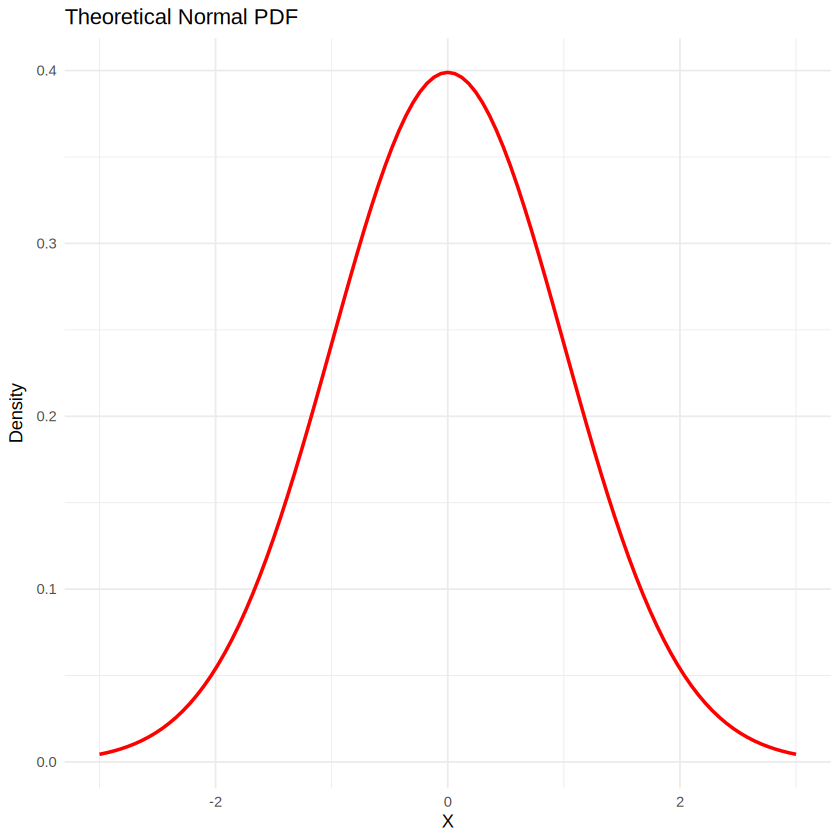

In [ ]:
ggplot(data.frame(x = c(-3, 3)), aes(x = x)) +
  stat_function(fun = dnorm, args = list(mean = 0, sd = 1), color = "red", linewidth = 1) +
  theme_minimal() +
  labs(title = "Theoretical Normal PDF", x = "X", y = "Density")

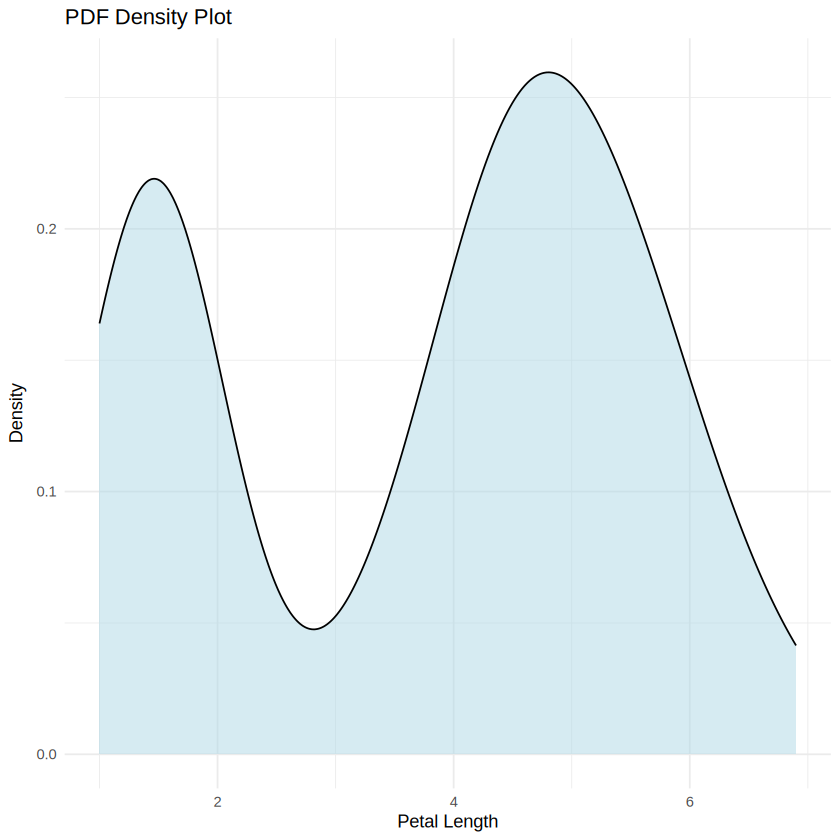

In [ ]:
library(ggplot2)
ggplot(iris, aes(x = Petal.Length)) +
  geom_density(fill = "lightblue", alpha = 0.5) +
  theme_minimal() +
  labs(title = "PDF Density Plot", x = "Petal Length", y = "Density")

In [ ]:
ggplot(iris, aes(x = Petal.Length)) +
  stat_ecdf(geom = "step", color = "darkgreen", linewidth = 1) +
  theme_minimal() +
  labs(title = "Empirical CDF Plot", x = "Petal Length", y = "Cumulative Probability")

ERROR: Error in ggplot(iris, aes(x = Petal.Length)): could not find function "ggplot"


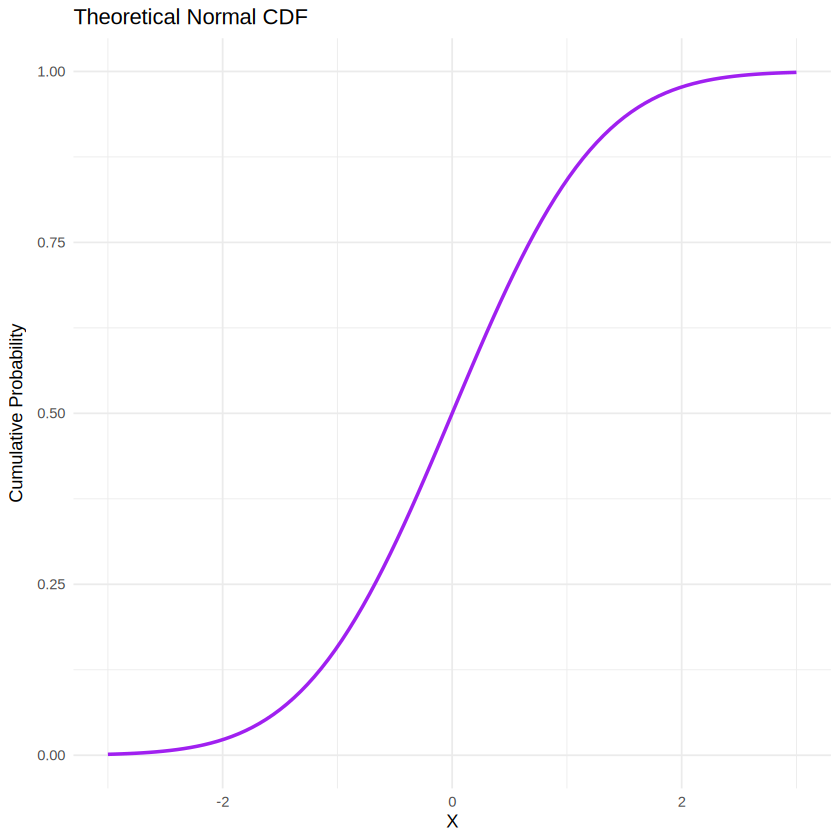

In [ ]:
ggplot(data.frame(x = c(-3, 3)), aes(x = x)) +
  stat_function(fun = pnorm, args = list(mean = 0, sd = 1), color = "purple", linewidth = 1) +
  theme_minimal() +
  labs(title = "Theoretical Normal CDF", x = "X", y = "Cumulative Probability")

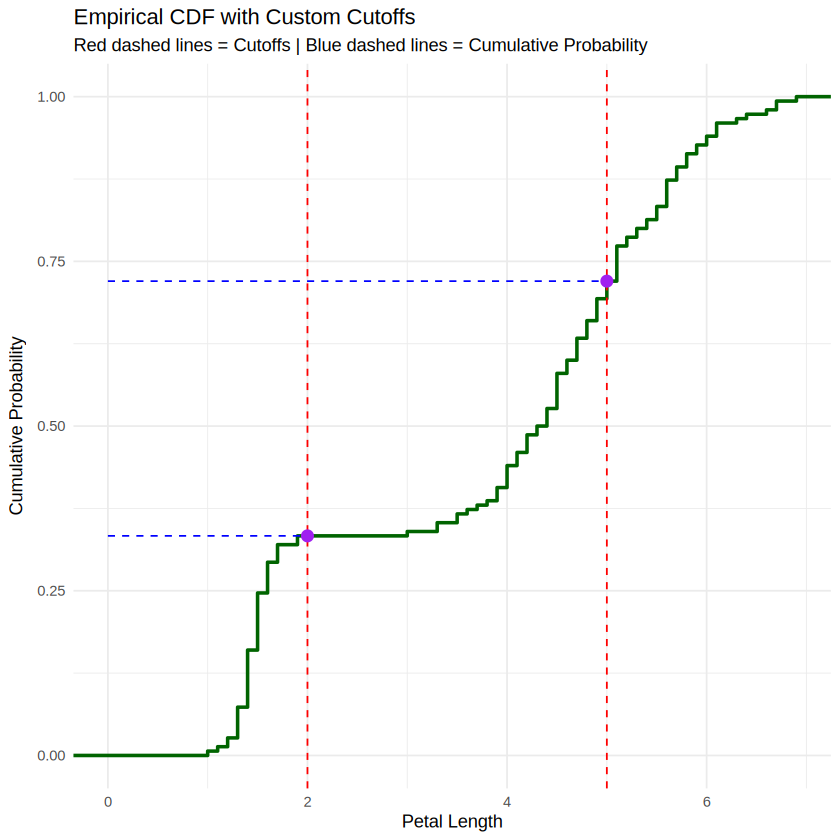

In [ ]:
library(ggplot2)

# 1. Define your cutoffs of interest
cutoffs <- c(2.0, 5.0)

# 2. Calculate the exact cumulative probabilities at those cutoffs using ecdf()
ecdf_fun <- ecdf(iris$Petal.Length)
cutoff_probs <- ecdf_fun(cutoffs)

# Combine into a data frame for plotting intersection points
cutoff_data <- data.frame(x = cutoffs, y = cutoff_probs)

# 3. Create the plot
ggplot(iris, aes(x = Petal.Length)) +
  # Draw the empirical CDF step curve
  stat_ecdf(geom = "step", color = "darkgreen", linewidth = 1) +

  # Add vertical lines at your cutoffs (X-axis)
  geom_vline(xintercept = cutoffs, linetype = "dashed", color = "red") +

  # Add horizontal lines pointing to the cumulative probability (Y-axis)
  geom_segment(data = cutoff_data, aes(x = 0, xend = x, y = y, yend = y),
               linetype = "dashed", color = "blue") +

  # Highlight the intersection points
  geom_point(data = cutoff_data, aes(x = x, y = y), color = "purple", size = 3) +

  # Styling and labels
  theme_minimal() +
  labs(
    title = "Empirical CDF with Custom Cutoffs",
    subtitle = "Red dashed lines = Cutoffs | Blue dashed lines = Cumulative Probability",
    x = "Petal Length",
    y = "Cumulative Probability"
  )

          CDF & CUTOFF SUMMARY REPORT             

--- Cumulative Probabilities ---
P(X <= 2.0) = 0.3333 (33.3%)
P(X <= 5.0) = 0.7200 (72.0%)

--- Value Breakdown (Total N = 150 ) ---
1. Below 2.0:        50 values  (33.3%)
2. Within (2.0–5.0): 58 values  (38.7%)
3. Above 5.0:        42 values  (28.0%)



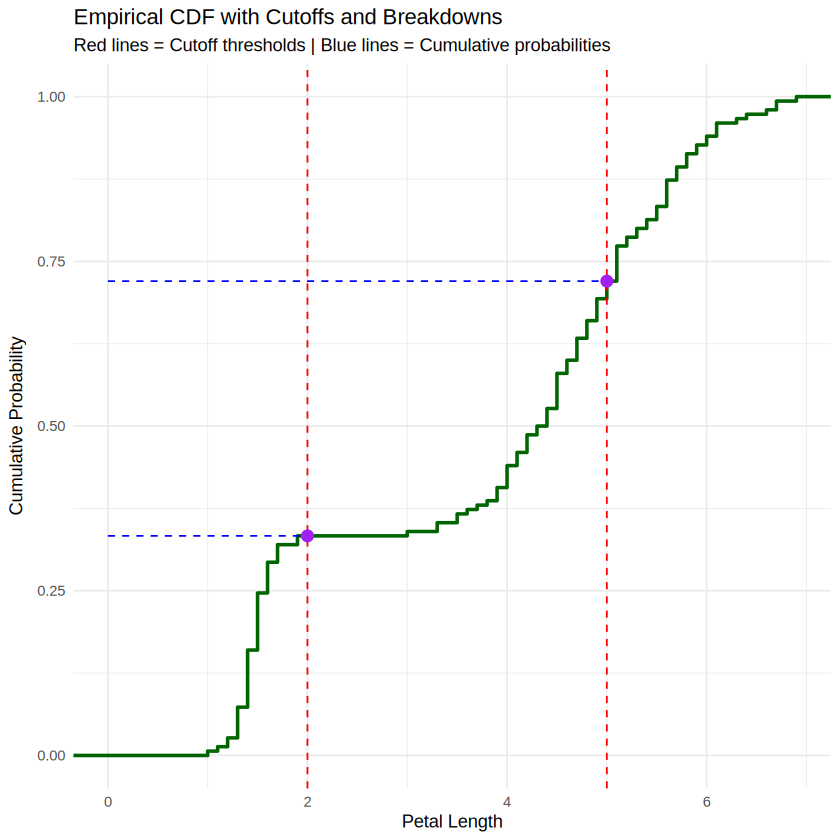

In [ ]:
library(ggplot2)

# 1. Define your cutoffs and data
cutoffs <- c(2.0, 5.0)
lower_cut <- cutoffs[1]
upper_cut <- cutoffs[2]
data_vals <- iris$Petal.Length
total_n <- length(data_vals)

# 2. Calculate Cumulative Probabilities
ecdf_fun <- ecdf(data_vals)
cutoff_probs <- ecdf_fun(cutoffs)
cutoff_data <- data.frame(x = cutoffs, y = cutoff_probs)

# 3. Calculate the Value Breakdown (Counts & Percentages)
n_below  <- sum(data_vals <= lower_cut)
n_within <- sum(data_vals > lower_cut & data_vals <= upper_cut)
n_above  <- sum(data_vals > upper_cut)

pct_below  <- (n_below / total_n) * 100
pct_within <- (n_within / total_n) * 100
pct_above  <- (n_above / total_n) * 100

# 4. Print Results to the Console
cat("==================================================\n")
cat("          CDF & CUTOFF SUMMARY REPORT             \n")
cat("==================================================\n\n")

cat("--- Cumulative Probabilities ---\n")
cat(sprintf("P(X <= %.1f) = %.4f (%.1f%%)\n", lower_cut, cutoff_probs[1], cutoff_probs[1]*100))
cat(sprintf("P(X <= %.1f) = %.4f (%.1f%%)\n", upper_cut, cutoff_probs[2], cutoff_probs[2]*100))

cat("\n--- Value Breakdown (Total N =", total_n, ") ---\n")
cat(sprintf("1. Below %.1f:        %d values  (%.1f%%)\n", lower_cut, n_below, pct_below))
cat(sprintf("2. Within (%.1f–%.1f): %d values  (%.1f%%)\n", lower_cut, upper_cut, n_within, pct_within))
cat(sprintf("3. Above %.1f:        %d values  (%.1f%%)\n", upper_cut, n_above, pct_above))
cat("==================================================\n\n")

# 5. Generate the Plot
ggplot(iris, aes(x = Petal.Length)) +
  stat_ecdf(geom = "step", color = "darkgreen", linewidth = 1) +
  geom_vline(xintercept = cutoffs, linetype = "dashed", color = "red") +
  geom_segment(data = cutoff_data, aes(x = 0, xend = x, y = y, yend = y),
               linetype = "dashed", color = "blue") +
  geom_point(data = cutoff_data, aes(x = x, y = y), color = "purple", size = 3) +
  theme_minimal() +
  labs(
    title = "Empirical CDF with Cutoffs and Breakdowns",
    subtitle = "Red lines = Cutoff thresholds | Blue lines = Cumulative probabilities",
    x = "Petal Length",
    y = "Cumulative Probability"
  )

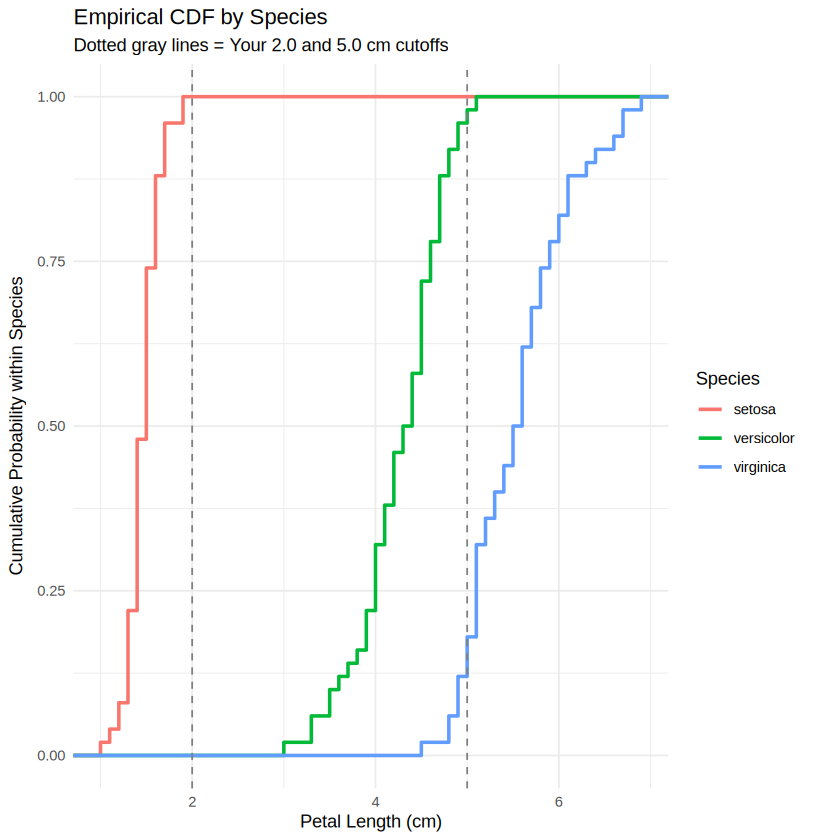

In [ ]:
library(ggplot2)

ggplot(iris, aes(x = Petal.Length, color = Species)) +
  # Draw separate step curves for each species
  stat_ecdf(geom = "step", linewidth = 1) +

  # Optional: Add your previous cutoffs to see how they split each species
  geom_vline(xintercept = c(2.0, 5.0), linetype = "dashed", color = "gray50") +

  # Styling and labels
  theme_minimal() +
  labs(
    title = "Empirical CDF by Species",
    subtitle = "Dotted gray lines = Your 2.0 and 5.0 cm cutoffs",
    x = "Petal Length (cm)",
    y = "Cumulative Probability within Species"
  )

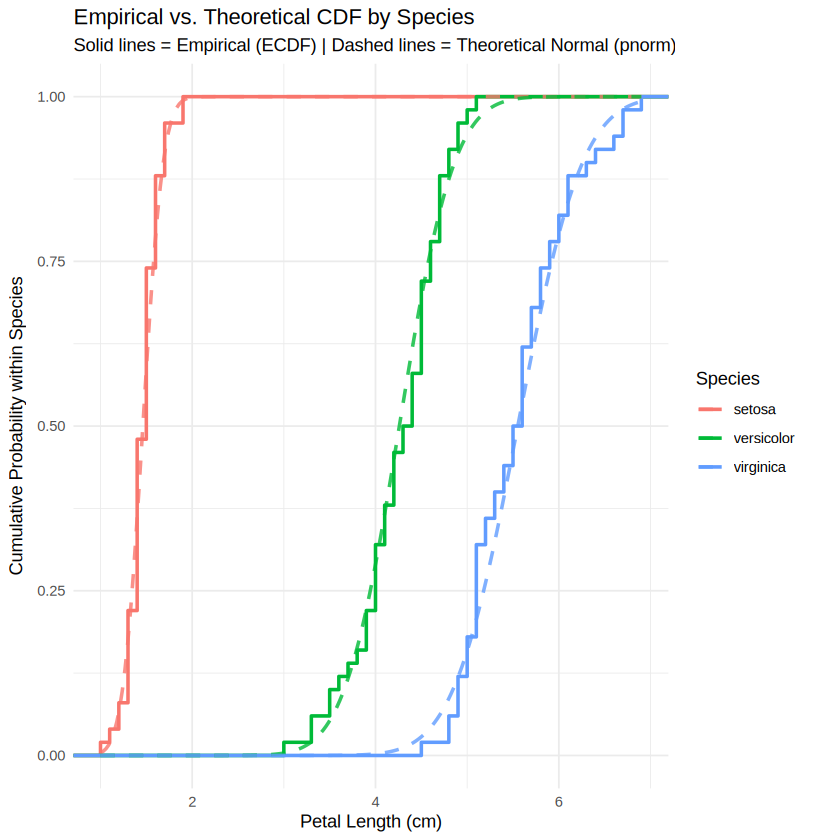

In [ ]:
# 1. Calculate mean and standard deviation for each species using dplyr
params <- iris %>%
  group_by(Species) %>%
  summarise(
    mean_len = mean(Petal.Length),
    sd_len = sd(Petal.Length)
  )

# 2. Create a grid of x-values and combine with species parameters using tidyr::crossing
x_grid <- seq(min(iris$Petal.Length), max(iris$Petal.Length), length.out = 200)

df_theoretical <- params %>%
  crossing(Petal.Length = x_grid) %>%
  mutate(cdf = pnorm(Petal.Length, mean = mean_len, sd = sd_len))

# 3. Plot both empirical and theoretical curves together
ggplot() +
  # Empirical CDF (Step lines)
  stat_ecdf(data = iris, aes(x = Petal.Length, color = Species), geom = "step", linewidth = 1) +

  # Theoretical Normal CDF (Smooth dashed lines)
  geom_line(data = df_theoretical, aes(x = Petal.Length, y = cdf, color = Species),
            linetype = "dashed", linewidth = 1, alpha = 0.8) +

  # Optional cutoffs
  #geom_vline(xintercept = c(2.0, 5.0), linetype = "dotted", color = "gray50") +

  # Styling and labels
  theme_minimal() +
  labs(
    title = "Empirical vs. Theoretical CDF by Species",
    subtitle = "Solid lines = Empirical (ECDF) | Dashed lines = Theoretical Normal (pnorm)",
    x = "Petal Length (cm)",
    y = "Cumulative Probability within Species",
    color = "Species"
  )

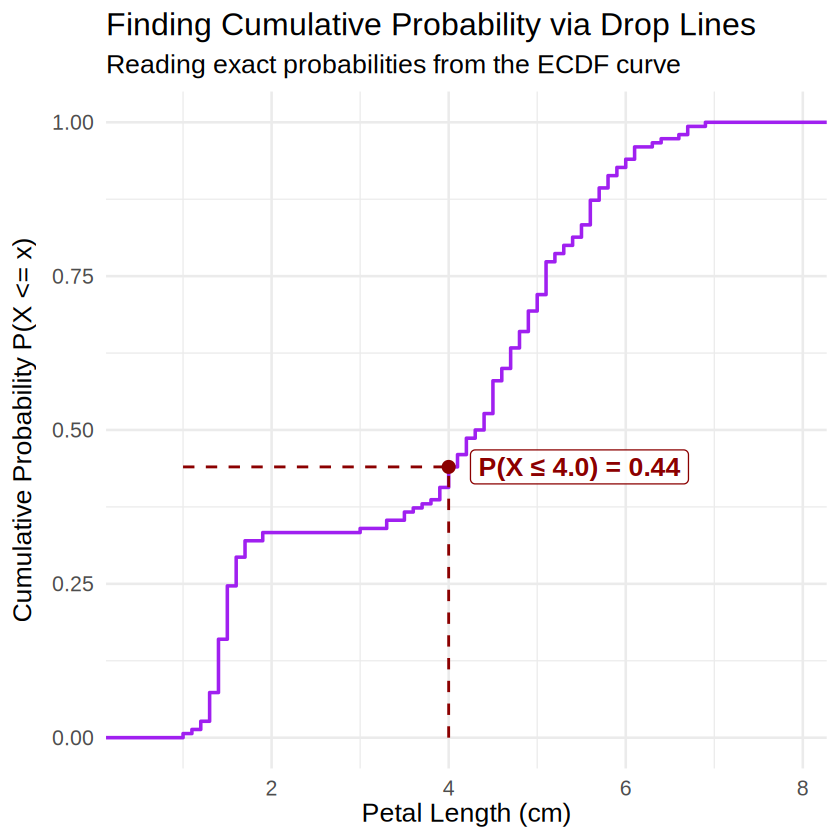

In [ ]:
library(ggplot2)

# 1. Pre-calculate values cleanly outside ggplot
x_target <- 4.0
y_target <- ecdf(iris$Petal.Length)(x_target)
min_x    <- min(iris$Petal.Length)

# 2. Create the plot
ggplot(iris, aes(x = Petal.Length)) +
  # The Empirical CDF step curve (uses the 150 rows of iris data)
  stat_ecdf(geom = "step", color = "purple", linewidth = 1) +

  # Vertical drop line from X-axis up to the curve
  annotate("segment", x = x_target, y = 0, xend = x_target, yend = y_target,
           linetype = "dashed", color = "darkred", linewidth = 0.8) +

  # Horizontal drop line from the curve across to the Y-axis
  annotate("segment", x = min_x, y = y_target, xend = x_target, yend = y_target,
           linetype = "dashed", color = "darkred", linewidth = 0.8) +

  # Highlight the exact intersection point
  annotate("point", x = x_target, y = y_target, color = "darkred", size = 3) +

  # Text label box
  annotate("label",
           x = x_target,
           y = y_target,
           label = sprintf("P(X ≤ %.1f) = %.2f", x_target, y_target),
           hjust = -0.1,
           vjust = 0.5,
           color = "darkred",
           fontface = "bold",
           fill = "white",
           alpha = 0.8) +

  # Styling and axis limits
  xlim(min_x - 0.5, max(iris$Petal.Length) + 1.0) +
  theme_minimal(base_size = 16) +
  labs(
    title = "Finding Cumulative Probability via Drop Lines",
    subtitle = "Reading exact probabilities from the ECDF curve",
    x = "Petal Length (cm)",
    y = "Cumulative Probability P(X <= x)"
  )

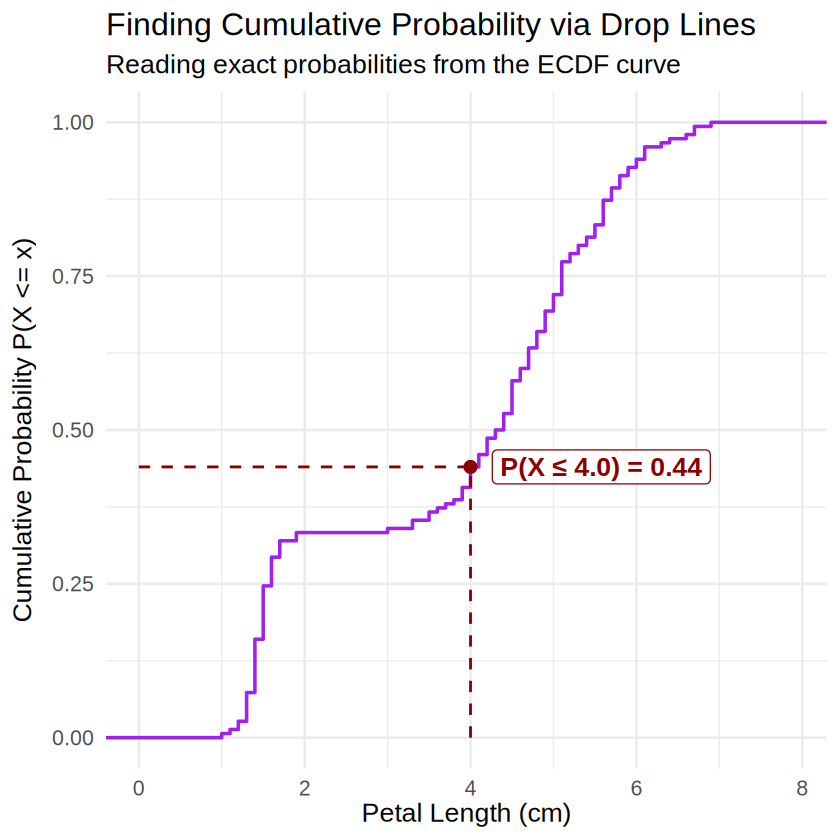

In [ ]:
library(ggplot2)

# 1. Pre-calculate values cleanly outside ggplot
x_target <- 4.0
y_target <- ecdf(iris$Petal.Length)(x_target)
max_x    <- max(iris$Petal.Length)

# 2. Create the plot
ggplot(iris, aes(x = Petal.Length)) +
  # The Empirical CDF step curve
  stat_ecdf(geom = "step", color = "purple", linewidth = 1) +

  # Vertical drop line from X-axis up to the curve
  annotate("segment", x = x_target, y = 0, xend = x_target, yend = y_target,
           linetype = "dashed", color = "darkred", linewidth = 0.8) +

  # Horizontal drop line from the curve all the way to x = 0 (the Y-axis)
  annotate("segment", x = 0, y = y_target, xend = x_target, yend = y_target,
           linetype = "dashed", color = "darkred", linewidth = 0.8) +

  # Highlight the exact intersection point
  annotate("point", x = x_target, y = y_target, color = "darkred", size = 3) +

  # Text label box
  annotate("label",
           x = x_target,
           y = y_target,
           label = sprintf("P(X ≤ %.1f) = %.2f", x_target, y_target),
           hjust = -0.1,
           vjust = 0.5,
           color = "darkred",
           fontface = "bold",
           fill = "white",
           alpha = 0.8) +

  # FIX: Start the X-axis at 0 so the horizontal segment is fully inside the scale
  scale_x_continuous(limits = c(0, max_x + 1.0)) +
  theme_minimal(base_size = 16) +
  labs(
    title = "Finding Cumulative Probability via Drop Lines",
    subtitle = "Reading exact probabilities from the ECDF curve",
    x = "Petal Length (cm)",
    y = "Cumulative Probability P(X <= x)"
  )

### Quiz
In a CDF plot why all the curves start at x-min and ends at x-max.

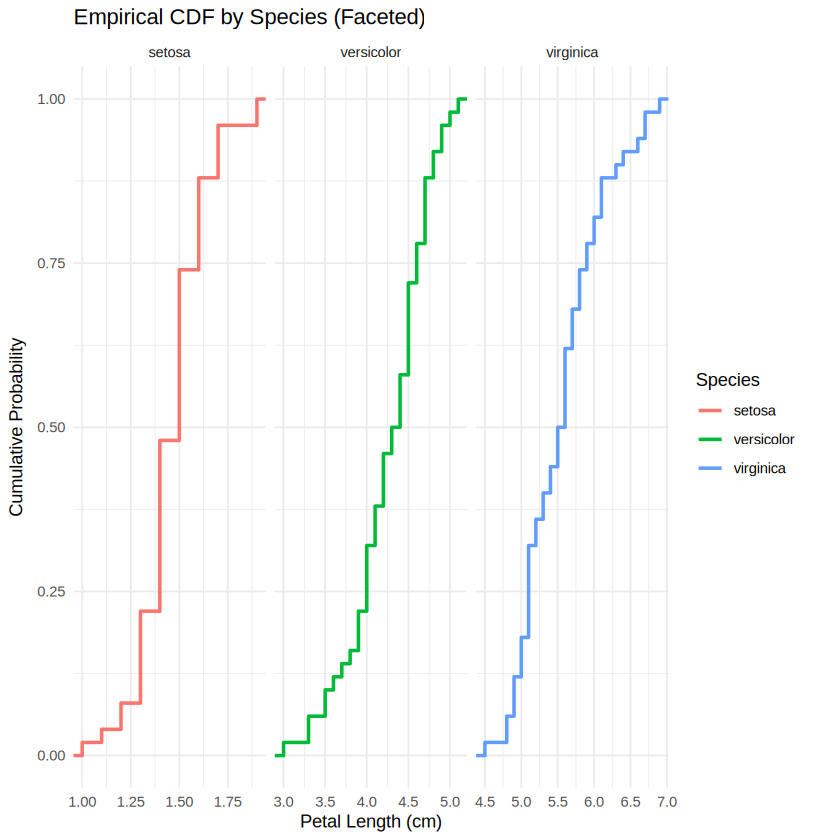

In [ ]:
library(ggplot2)

ggplot(iris, aes(x = Petal.Length, color = Species)) +
  stat_ecdf(geom = "step", linewidth = 1) +
  # This splits them into separate panels so they don't overlap
  facet_wrap(~ Species, scales = "free_x") +
  theme_minimal() +
  labs(
    title = "Empirical CDF by Species (Faceted)",
    x = "Petal Length (cm)",
    y = "Cumulative Probability"
  )

In [ ]:
install.packages("ggridges")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Picking joint bandwidth of 0.155



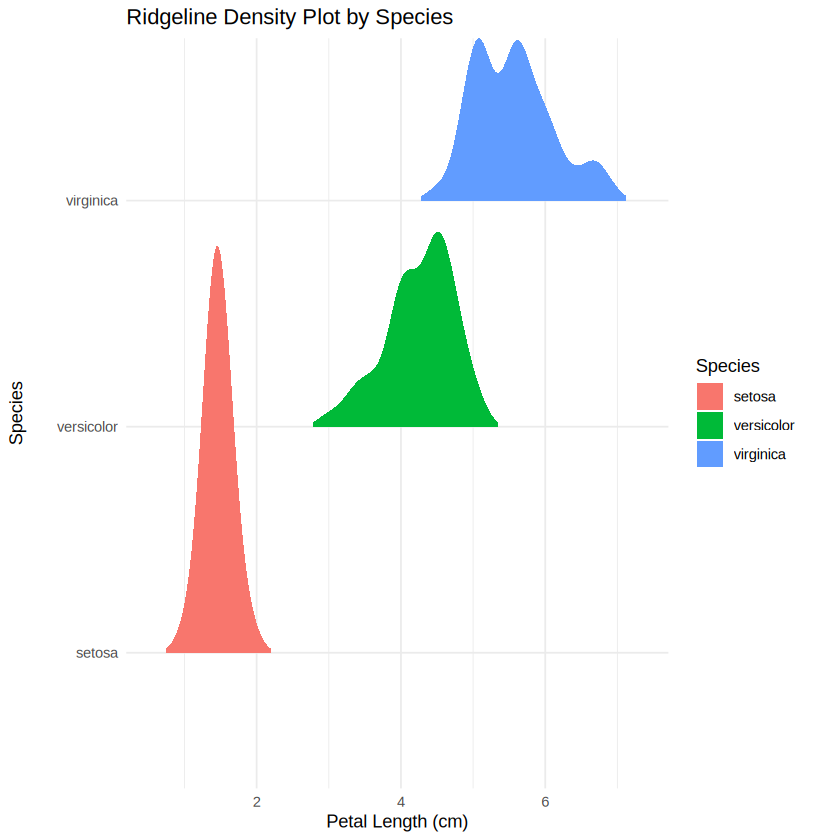

In [ ]:
library(ggridges)

ggplot(iris, aes(x = Petal.Length, y = Species, fill = Species)) +
  geom_density_ridges(rel_min_height = 0.01, color = NA) +
  theme_minimal() +
  labs(
    title = "Ridgeline Density Plot by Species",
    x = "Petal Length (cm)",
    y = "Species"
  )

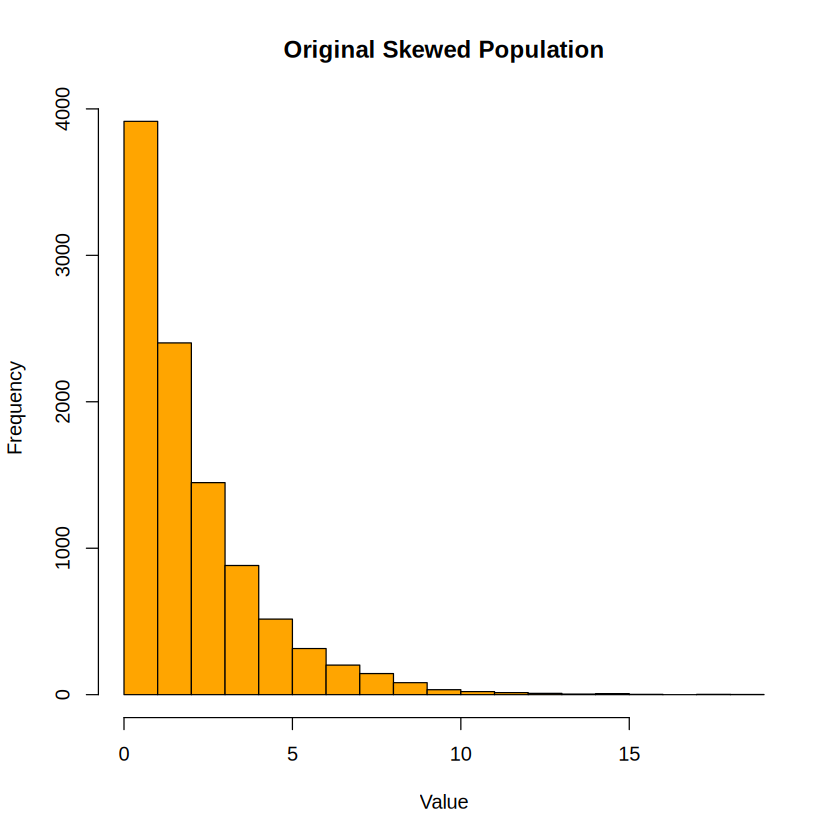

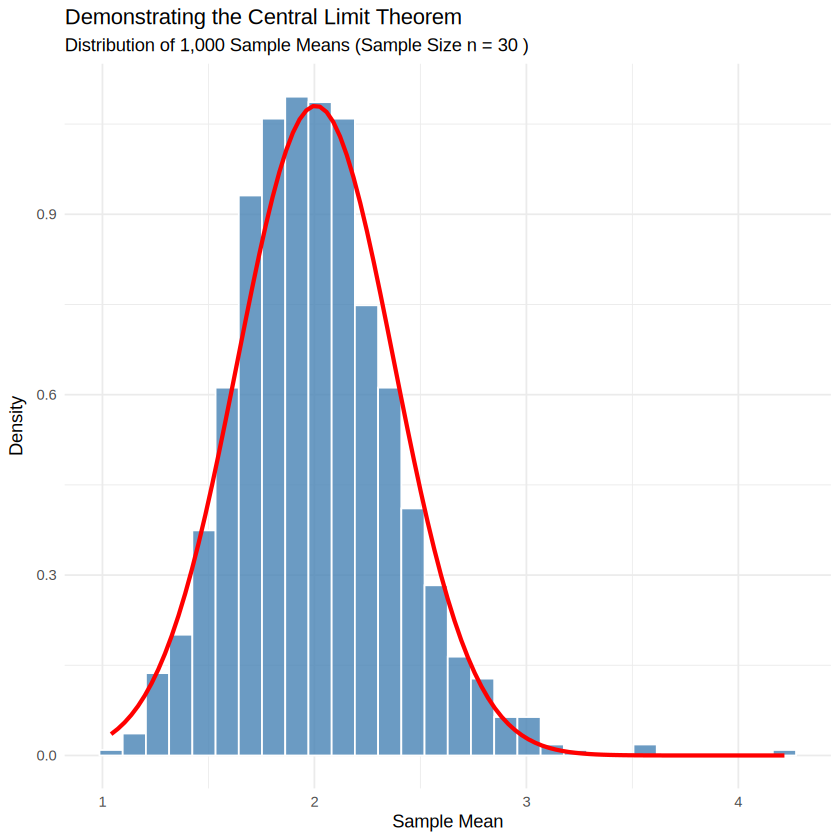

In [ ]:
library(ggplot2)

# 1. Set seed for reproducible student results
set.seed(123)

# 2. Create a heavily skewed population (Exponential distribution)
# Imagine this is waiting time or medical costs — definitely not normal!
population_size <- 10000
population_data <- rexp(n = population_size, rate = 0.5)

# Quick look at the population
hist(population_data, main = "Original Skewed Population", col = "orange", xlab = "Value")

# 3. Simulate the Central Limit Theorem
# We will draw 1,000 different samples, each of size n = 30, and calculate their means
sample_size <- 30
n_simulations <- 1000

sample_means <- replicate(n_simulations, {
  # Take a random sample from our population
  current_sample <- sample(population_data, size = sample_size, replace = TRUE)
  # Calculate and return its mean
  mean(current_sample)
})

# 4. Visualize the Resulting Sample Means
df_means <- data.frame(Mean = sample_means)

ggplot(df_means, aes(x = Mean)) +
  # Histogram of the sample means
  geom_histogram(aes(y = after_stat(density)), bins = 30, fill = "steelblue", color = "white", alpha = 0.8) +
  # Overlay a theoretical normal curve to show how well it fits
  stat_function(
    fun = dnorm,
    args = list(mean = mean(sample_means), sd = sd(sample_means)),
    color = "red",
    linewidth = 1.2
  ) +
  theme_minimal() +
  labs(
    title = "Demonstrating the Central Limit Theorem",
    subtitle = paste("Distribution of 1,000 Sample Means (Sample Size n =", sample_size, ")"),
    x = "Sample Mean",
    y = "Density"
  )

Uniform: runif(n, min, max) — Great for flat, equal-probability data.

Normal: rnorm(n, mean, sd) — The classic bell curve for parametric testing.

Binomial: rbinom(n, size, prob) — Perfect for yes/no, success/failure, or coin-flip scenarios.

Poisson: rpois(n, lambda) — Ideal for count data (e.g., number of hospital visits per week).

Exponential: rexp(n, rate) — Excellent for modeling time-to-event or waiting times (often used to show right-skewness).

Tip: Always remember to use set.seed() right before your random functions

d* = Density (PDF)

p* = Cumulative probability (CDF)

q* = Quantiles

r* = Random generation

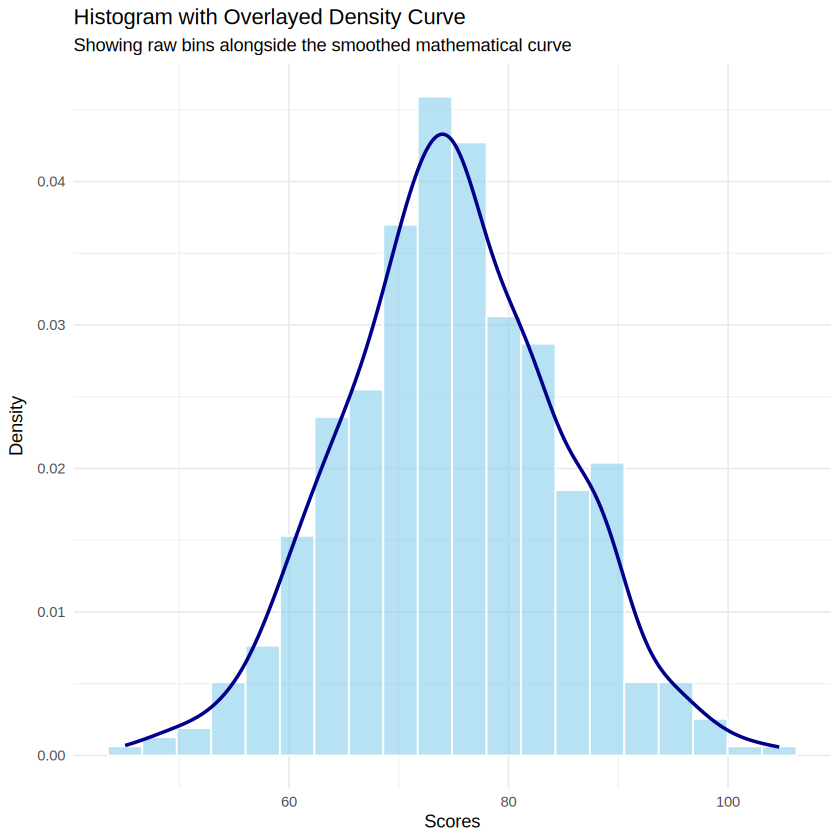

In [ ]:
# Load required libraries
library(ggplot2)

# Generate synthetic continuous data
set.seed(42)
df <- data.frame(score = rnorm(n = 500, mean = 75, sd = 10))

# Create the combined plot
ggplot(df, aes(x = score)) +
  # 1. Histogram scaled to density
  geom_histogram(aes(y = after_stat(density)),
                 bins = 20,
                 fill = "skyblue",
                 color = "white",
                 alpha = 0.6) +
  # 2. Overlayed density curve
  geom_density(color = "darkblue", linewidth = 1) +
  # Labels and theme
  labs(title = "Histogram with Overlayed Density Curve",
       subtitle = "Showing raw bins alongside the smoothed mathematical curve",
       x = "Scores",
       y = "Density") +
  theme_minimal()

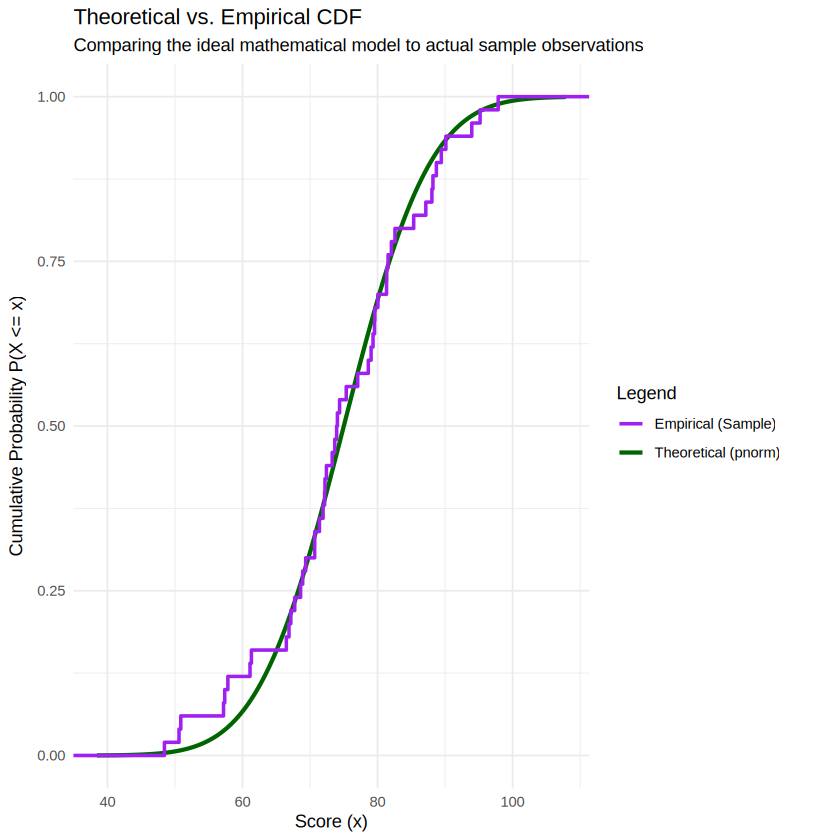

In [ ]:
# Load required libraries
library(ggplot2)

# Set parameters
mean_val <- 75
sd_val <- 10

# 1. Generate empirical (sample) data
set.seed(42)
df_empirical <- data.frame(score = rnorm(n = 50, mean = mean_val, sd = sd_val))

# 2. Generate theoretical curve data
x_vals <- seq(min(df_empirical$score) - 10, max(df_empirical$score) + 10, length.out = 500)
df_theoretical <- data.frame(
  score = x_vals,
  cdf = pnorm(x_vals, mean = mean_val, sd = sd_val)
)

# 3. Create the combined plot
ggplot() +
  # Theoretical smooth CDF curve
  geom_line(data = df_theoretical, aes(x = score, y = cdf, color = "Theoretical (pnorm)"), linewidth = 1.2) +
  # Empirical step CDF from sample data
  stat_ecdf(data = df_empirical, aes(x = score, color = "Empirical (Sample)"), geom = "step", linewidth = 1) +
  # Customizing colors and labels
  scale_color_manual(values = c("Theoretical (pnorm)" = "darkgreen", "Empirical (Sample)" = "purple")) +
  labs(title = "Theoretical vs. Empirical CDF",
       subtitle = "Comparing the ideal mathematical model to actual sample observations",
       x = "Score (x)",
       y = "Cumulative Probability P(X <= x)",
       color = "Legend") +
  theme_minimal()

ERROR: Error in df_empirical.summarise(): could not find function "df_empirical.summarise"
